# Lecture 3: Generalization and Regularization

This notebook contains worked examples and computational demonstrations for the companion slides.

[Open in Google Colab](https://colab.research.google.com/github/DrFarrukh/teaching/blob/main/courses/artificial-neural-networks/lectures/lecture-03/notebook.ipynb). Upload the notebook to Google Colab and select **Runtime → Run all**. The examples use synthetic data and need no file uploads.


In [ ]:
# Google Colab includes these packages in its standard runtime.
# Uncomment this line only if a package is missing:
# %pip install torch numpy matplotlib


In [1]:
# Example 0: Setup
import math
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.set_num_threads(1)
DTYPE = torch.float64
torch.manual_seed(31)
COLORS = ["#2F75B5", "#2F7D64", "#C74B50", "#B57A12"]
plt.rcParams.update({"figure.figsize": (10.5, 5.4), "font.size": 13,
                     "axes.titlesize": 17, "axes.labelsize": 14,
                     "legend.fontsize": 11, "axes.grid": True,
                     "grid.alpha": 0.2, "figure.dpi": 110})


def finish(name=None):
    plt.tight_layout()
    plt.show()
    plt.close()


def mse(prediction, target):
    assert prediction.shape == target.shape
    return float(np.mean((prediction - target)**2))


print("NumPy:", np.__version__, "PyTorch:", torch.__version__)
print("CPU / float64 / MSE without 1/2 / unpenalized intercept")

NumPy: 2.5.3 PyTorch: 2.14.0+cu130
CPU / float64 / MSE without 1/2 / unpenalized intercept


In [2]:
# Example 1: Hand-check the evidence
hand_errors = {"A": ([0, 0, 0], [2, -2]),
               "B": ([0.5, -0.5, 0], [0.5, -0.5])}
for name, (tr, va) in hand_errors.items():
    print(f"{name}: train MSE={np.mean(np.square(tr)):.6f}; "
          f"validation MSE={np.mean(np.square(va)):.6f}")
print("Choose B by validation. Test evidence is still held back.")

A: train MSE=0.000000; validation MSE=4.000000
B: train MSE=0.166667; validation MSE=0.250000
Validation selects B; the test set remains reserved for final evaluation.


We use y=1+2x−1.5x²+ε with independent ε~N(0,0.25²). The true law is visible
for teaching but is never used to choose a candidate. In a real application
we would not know it. These rows are IID; subject dependence comes later.

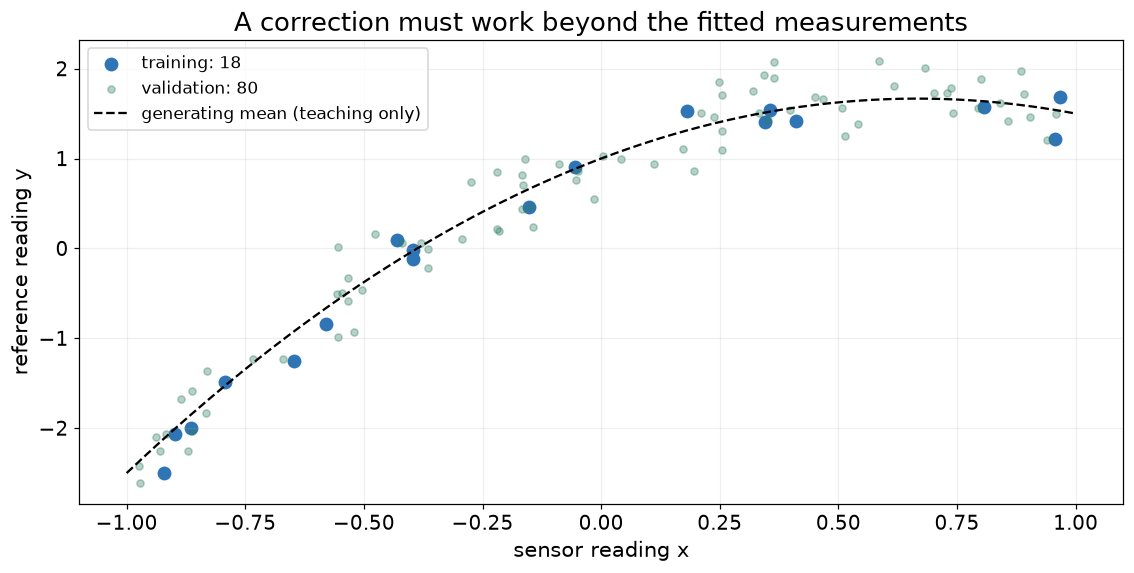

Test set: 200 separate IID observations, held for final model evaluation.


In [3]:
# Example 2: Freeze disjoint IID splits before fitting
data_rng = np.random.default_rng(31)


def true_law(x):
    return 1 + 2*x - 1.5*x**2


def sample_data(rng, n):
    x = rng.uniform(-1, 1, (n, 1))
    return x, true_law(x) + 0.25*rng.normal(size=(n, 1))


x_train, y_train = sample_data(data_rng, 18)
x_val, y_val = sample_data(data_rng, 80)
x_test, y_test = sample_data(data_rng, 200)
grid = np.linspace(-1, 1, 401).reshape(-1, 1)
plt.scatter(x_train, y_train, s=65, color=COLORS[0], label="training: 18")
plt.scatter(x_val, y_val, s=22, alpha=0.35, color=COLORS[1], label="validation: 80")
plt.plot(grid, true_law(grid), "k--", label="generating mean (teaching only)")
plt.title("A correction must work beyond the fitted measurements")
plt.xlabel("sensor reading x"); plt.ylabel("reference reading y"); plt.legend()
finish("01_calibration_data")
print("Test set: 200 separate IID observations, held for final model evaluation.")

We use a least-squares solver here to isolate model capacity from optimizer
speed. This is a diagnostic reference, not a replacement for Lecture 2's
training loop. At a global least-squares solution, nested polynomial families
cannot increase training error as degree grows (up to numerical error).

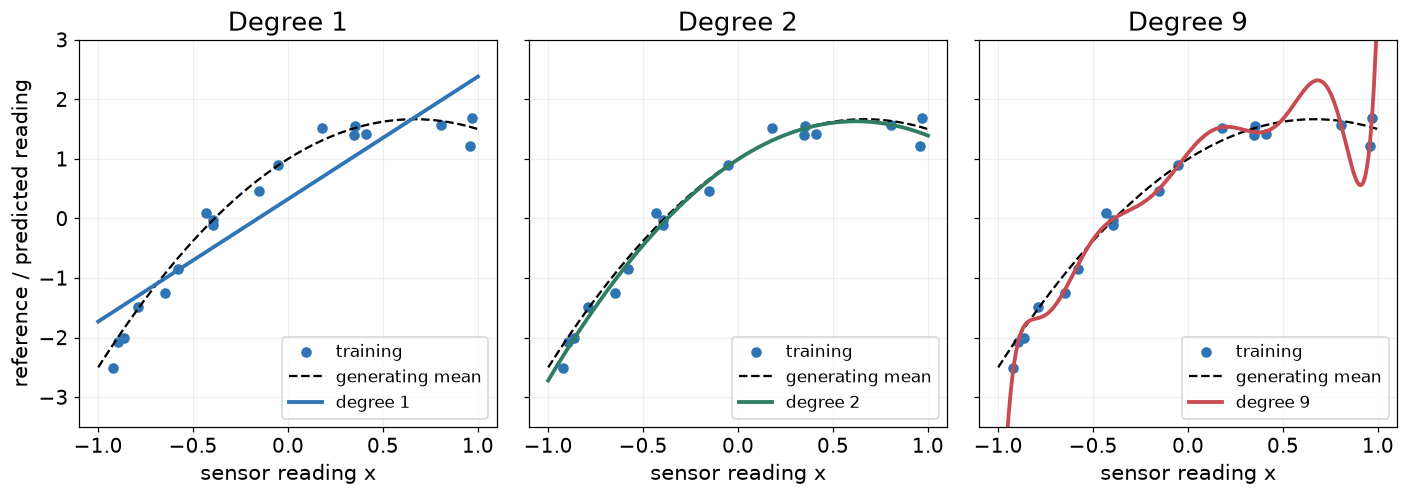

degree   train MSE   validation MSE
     1     0.32626          0.30914
     2     0.02591          0.07209
     3     0.02562          0.07380
     4     0.02544          0.07596
     5     0.02517          0.07815
     6     0.02479          0.08078
     7     0.02460          0.08093
     8     0.02101          0.13929
     9     0.00819          0.29333
    10     0.00698          0.21757
    11     0.00640          0.23388
    12     0.00511          0.14458
    13     0.00492          0.33824


In [4]:
# Example 3: Fit three capacities with a least-squares reference
def raw_features(x, degree):
    return x ** np.arange(1, degree + 1).reshape(1, -1)


def design(x, degree):
    return np.column_stack([np.ones(len(x)), raw_features(x, degree)])


degree_candidates = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
degree_candidates = np.linspace(1,13,13).astype(np.int_)

degree_models = {}
degree_rows = []
for degree in degree_candidates:
    coef = np.linalg.lstsq(design(x_train, degree), y_train, rcond=None)[0]
    degree_models[degree] = coef
    degree_rows.append([degree, mse(design(x_train, degree)@coef, y_train),
                        mse(design(x_val, degree)@coef, y_val)])
fig, axes = plt.subplots(1, 3, figsize=(13, 4.7), sharex=True, sharey=True)
for ax, degree, color in zip(axes, [1, 2, 9], COLORS):
    ax.scatter(x_train, y_train, s=35, color=COLORS[0], label="training")
    ax.plot(grid, true_law(grid), "k--", label="generating mean")
    ax.plot(grid, design(grid, degree)@degree_models[degree], color=color,
            lw=2.5, label=f"degree {degree}")
    ax.set(title=f"Degree {degree}", xlabel="sensor reading x", ylim=(-3.5, 3))
    ax.legend(loc="lower right")
axes[0].set_ylabel("reference / predicted reading")
finish("02_polynomial_fits")
print("degree   train MSE   validation MSE")
for d, tr, va in degree_rows:
    print(f"{d:6d} {tr:11.5f} {va:16.5f}")

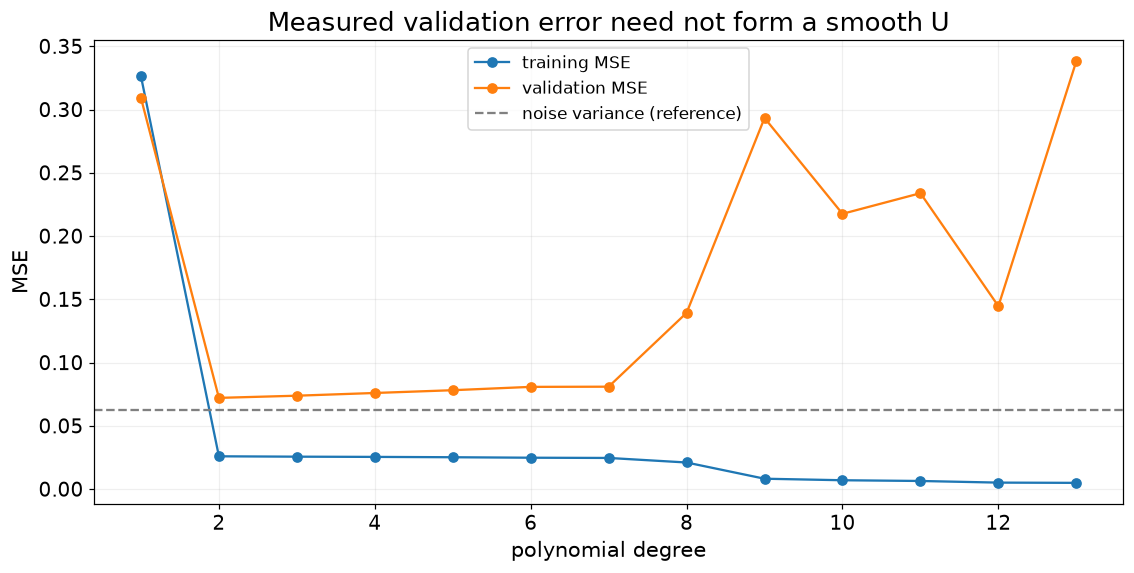

Best degree on this validation set: 2


In [5]:
# Example 4: Plot measured error against capacity
degree_table = np.array(degree_rows)
assert np.all(np.diff(degree_table[:, 1]) <= 1e-10)
plt.plot(degree_table[:, 0], degree_table[:, 1], "o-", label="training MSE")
plt.plot(degree_table[:, 0], degree_table[:, 2], "o-", label="validation MSE")
plt.axhline(0.25**2, color="gray", ls="--", label="noise variance (reference)")
plt.xlabel("polynomial degree"); plt.ylabel("MSE")
plt.xticks = degree_candidates
plt.title("Measured validation error need not form a smooth U")
plt.legend(); finish("03_capacity_errors")
best_degree = min(degree_rows, key=lambda row: row[2])[0]
print("Best degree on this validation set:", best_degree)

In [6]:
# Example 5: Fit and retain training-only feature statistics
RIDGE_DEGREE = 9
phi_train = raw_features(x_train, RIDGE_DEGREE)
feature_mean = phi_train.mean(axis=0, keepdims=True)
feature_scale = phi_train.std(axis=0, keepdims=True)
feature_scale = np.where(feature_scale > 1e-12, feature_scale, 1.0)


def transform(x):
    return (raw_features(x, RIDGE_DEGREE)-feature_mean)/feature_scale


z_train, z_val = transform(x_train), transform(x_val)
assert np.allclose(z_train.mean(axis=0), 0, atol=1e-12)
assert np.allclose(z_train.std(axis=0), 1, atol=1e-12)
print("Training feature means after scaling:", np.round(z_train.mean(0), 8))
print("Validation means need not be zero:", np.round(z_val.mean(0), 3))
print("Selecting an epoch on validation is model selection: test remains separate.")

Training feature means after scaling: [ 0.  0.  0. -0.  0.  0.  0.  0. -0.]
Validation means need not be zero: [ 0.18  -0.227  0.076 -0.227 -0.007 -0.232 -0.069 -0.234 -0.116]
Selecting an epoch on validation is model selection: test remains separate.


We leave the bias unpenalized. The data term retains Lecture 2's MSE
convention. λ=0 recovers the unregularized objective. For ordinary SGD with
no momentum, the L2 term produces the displayed weight-decay update.
This equivalence does not transfer unchanged to every optimizer.

In [7]:
# Example 6: Verify the regularized hand update independently
X_hand = torch.eye(2, dtype=DTYPE)
y_hand = torch.tensor([[1.], [2.]], dtype=DTYPE)
w_hand = torch.tensor([[2.], [-1.]], dtype=DTYPE, requires_grad=True)
b_hand = torch.tensor([0.5], dtype=DTYPE, requires_grad=True)
e_hand = X_hand@w_hand+b_hand-y_hand
data_loss = e_hand.square().mean()
penalty = 0.2/2*w_hand.square().sum()
objective = data_loss+penalty
objective.backward()
torch.testing.assert_close(w_hand.grad, torch.tensor([[1.9], [-2.7]], dtype=DTYPE))
torch.testing.assert_close(b_hand.grad, torch.tensor([-1.], dtype=DTYPE))
print("Residuals:", e_hand.detach().flatten().tolist())
print("MSE, penalty, objective:", data_loss.item(), penalty.item(), objective.item())
print("grad w:", w_hand.grad.flatten().tolist(), "grad b:", b_hand.grad.item())
with torch.no_grad():
    w_hand -= 0.1*w_hand.grad
    b_hand -= 0.1*b_hand.grad
print("Updated w:", w_hand.flatten().tolist(), "updated b:", b_hand.item())
assert np.allclose(w_hand.detach().numpy().ravel(), [1.81, -0.73])

Residuals: [1.5, -2.5]
MSE, penalty, objective: 4.25 0.5 4.75
grad w: [1.9, -2.7] grad b: -1.0
Updated w: [1.81, -0.73] updated b: 0.6


The following scratch trainer uses the explicit gradients we derived.
Every curve reports **unpenalized MSE**; the objective is recorded separately.
Full-batch SGD (gradient descent) makes the comparison deterministic.

λ=0: final train=0.02458, val=0.07820; objective=0.02458, weight norm=1.42639
λ=0.02: final train=0.02644, val=0.07703; objective=0.04282, weight norm=1.27987


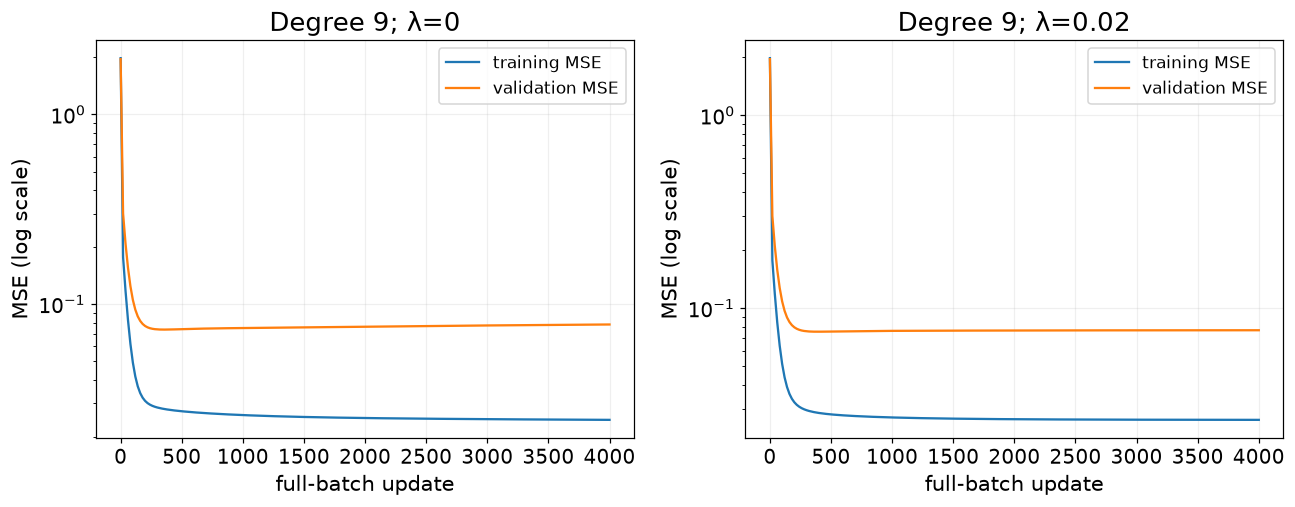

Finite training time also constrains the fit; these are not least-squares optima.


In [8]:
# Example 7: Manual gradients, training curves, and a regularized comparison
def train_scratch(z, targets, zv, yv, lam, steps=4000, lr=0.03):
    Z = torch.tensor(z, dtype=DTYPE)
    Y = torch.tensor(targets, dtype=DTYPE)
    ZV = torch.tensor(zv, dtype=DTYPE)
    YV = torch.tensor(yv, dtype=DTYPE)
    w = torch.zeros(Z.shape[1], 1, dtype=DTYPE)
    b = torch.zeros(1, dtype=DTYPE)
    history = []
    for step in range(steps+1):
        error = Z@w+b-Y
        loss = error.square().mean()
        if step % 20 == 0 or step == steps:
            history.append([step, loss.item(), ((ZV@w+b-YV)**2).mean().item(),
                            (loss+lam/2*w.square().sum()).item(), w.norm().item()])
        if step == steps:
            break
        grad_w = 2/len(Z)*Z.T@error + lam*w
        grad_b = 2*error.mean(dim=0)
        w -= lr*grad_w
        b -= lr*grad_b
    assert torch.isfinite(w).all()
    return w.numpy(), b.numpy(), np.array(history)


curve_runs = {lam: train_scratch(z_train, y_train, z_val, y_val, lam)
              for lam in [0.0, 0.02]}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, (lam, (_, _, hist)) in zip(axes, curve_runs.items()):
    ax.semilogy(hist[:, 0], hist[:, 1], label="training MSE")
    ax.semilogy(hist[:, 0], hist[:, 2], label="validation MSE")
    ax.set(title=f"Degree 9; λ={lam:g}", xlabel="full-batch update", ylabel="MSE (log scale)")
    ax.legend()
    print(f"λ={lam:g}: final train={hist[-1,1]:.5f}, val={hist[-1,2]:.5f}; "
          f"objective={hist[-1,3]:.5f}, weight norm={hist[-1,4]:.5f}")
finish("04_training_curves")
print("Finite training time also constrains the fit; these are not least-squares optima.")

A fair implementation comparison uses matched initialization, batch order, precision, learning rate, λ, and update count. The manual gradient, explicit autograd penalty, and `nn.Linear` optimizer weight decay should agree when each penalty is applied once.

In [9]:
# Example 8: Verify three equivalent implementations of ordinary SGD
LAM, LR, STEPS = 0.02, 0.03, 600
manual_w, manual_b, _ = train_scratch(z_train, y_train, z_val, y_val,
                                     LAM, steps=STEPS, lr=LR)
Z = torch.tensor(z_train, dtype=DTYPE)
Y = torch.tensor(y_train, dtype=DTYPE)
auto_w = torch.zeros(RIDGE_DEGREE, 1, dtype=DTYPE, requires_grad=True)
auto_b = torch.zeros(1, dtype=DTYPE, requires_grad=True)
net = nn.Linear(RIDGE_DEGREE, 1).to(dtype=DTYPE)
with torch.no_grad():
    net.weight.zero_(); net.bias.zero_()
optimizer = torch.optim.SGD([
    {"params": [net.weight], "weight_decay": LAM},
    {"params": [net.bias], "weight_decay": 0.0},
], lr=LR, momentum=0.0)
for _ in range(STEPS):
    explicit_objective = (Z@auto_w+auto_b-Y).square().mean()+LAM/2*auto_w.square().sum()
    explicit_objective.backward()
    with torch.no_grad():
        auto_w -= LR*auto_w.grad; auto_b -= LR*auto_b.grad
        auto_w.grad.zero_(); auto_b.grad.zero_()
    optimizer.zero_grad()
    framework_loss = nn.functional.mse_loss(net(Z), Y)
    framework_loss.backward()
    optimizer.step()
torch.testing.assert_close(auto_w, torch.tensor(manual_w), rtol=1e-10, atol=1e-12)
torch.testing.assert_close(auto_b, torch.tensor(manual_b), rtol=1e-10, atol=1e-12)
torch.testing.assert_close(net.weight.T, auto_w, rtol=1e-10, atol=1e-12)
torch.testing.assert_close(net.bias, auto_b, rtol=1e-10, atol=1e-12)
print("Manual gradient, autograd + explicit L2, and SGD(weight_decay) agree.")
print("Double-counting the penalty would apply 2λw, changing the experiment.")

Manual gradient, autograd + explicit L2, and SGD(weight_decay) agree.
Double-counting the penalty would apply 2λw, changing the experiment.


For a clean capacity comparison, solve each ridge objective to its
least-squares reference solution using an augmented design. The extra rows
encode sqrt(Nλ/2)w, with no intercept penalty. No matrix inverse is needed.
The factor Nλ/2 follows from our MSE convention. Solver mechanics are reserve
material; the lecture's learning rule is the gradient update above.

lambda       train MSE     validation MSE     weight norm
        0        0.00819            0.29333        98.26460
    1e-05        0.01616            0.11885        23.07571
   0.0001        0.02178            0.09144         4.51612
    0.001        0.02367            0.08265         1.68503
     0.01        0.02524            0.07718         1.34315
      0.1        0.03778            0.09090         1.09848
        1        0.17382            0.26315         0.66944
       10        0.79568            0.85374         0.29074


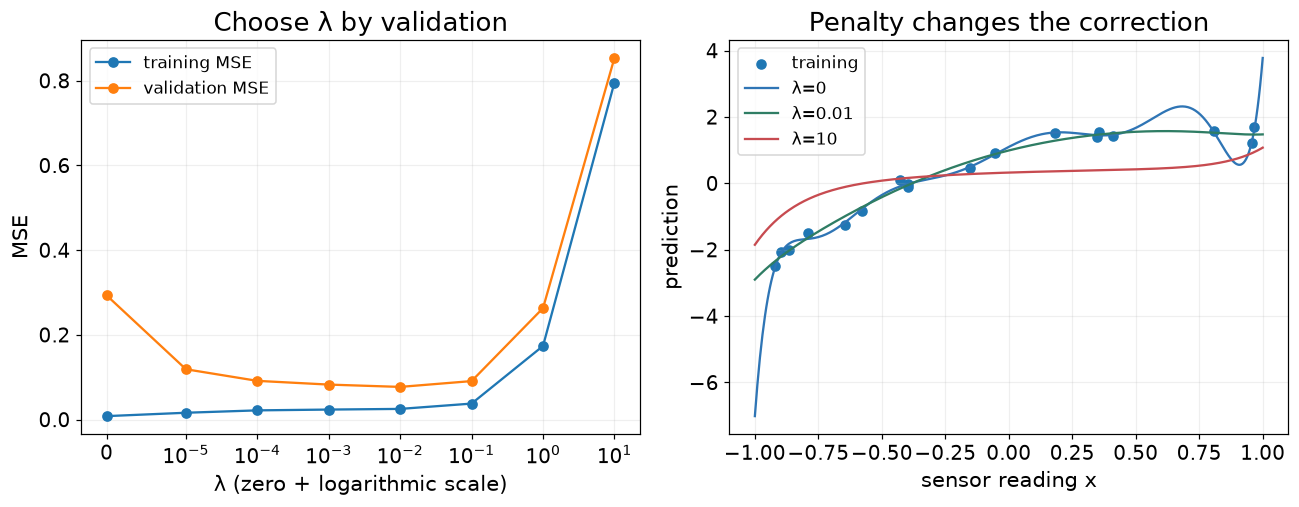

In [10]:
# Example 9: Select regularization using validation only
def ridge_reference(z, y, lam):
    A = np.column_stack([np.ones(len(z)), z])
    penalty_rows = np.column_stack([np.zeros(z.shape[1]), np.eye(z.shape[1])])
    A_aug = np.vstack([A, np.sqrt(len(z)*lam/2)*penalty_rows])
    y_aug = np.vstack([y, np.zeros((z.shape[1], 1))])
    return np.linalg.lstsq(A_aug, y_aug, rcond=None)[0]


lambdas = [0.0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0]
ridge_models, ridge_rows = {}, []
for lam in lambdas:
    coef = ridge_reference(z_train, y_train, lam)
    ridge_models[lam] = coef
    tr = mse(np.column_stack([np.ones(len(z_train)), z_train])@coef, y_train)
    va = mse(np.column_stack([np.ones(len(z_val)), z_val])@coef, y_val)
    ridge_rows.append([lam, tr, va, float(np.linalg.norm(coef[1:]))])
    # Independent stationarity check on the mathematical objective.
    err = z_train@coef[1:]+coef[0]-y_train
    assert np.max(np.abs(2/len(z_train)*z_train.T@err+lam*coef[1:])) < 1e-7
    assert abs(err.mean()) < 1e-9
ridge_table = np.array(ridge_rows)
print("lambda       train MSE     validation MSE     weight norm")
for row in ridge_rows:
    print(f"{row[0]:9g} {row[1]:14.5f} {row[2]:18.5f} {row[3]:15.5f}")
best_lambda = min(ridge_rows, key=lambda row: row[2])[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].plot(lambdas, ridge_table[:, 1], "o-", label="training MSE")
axes[0].plot(lambdas, ridge_table[:, 2], "o-", label="validation MSE")
axes[0].set_xscale("symlog", linthresh=1e-5)
axes[0].set(xlabel="λ (zero + logarithmic scale)", ylabel="MSE", title="Choose λ by validation")
axes[0].legend()
axes[1].scatter(x_train, y_train, s=35, label="training")
for lam, color in zip([0.0, best_lambda, 10.0], COLORS):
    pred = np.column_stack([np.ones(len(grid)), transform(grid)])@ridge_models[lam]
    axes[1].plot(grid, pred, color=color, label=f"λ={lam:g}")
axes[1].set(xlabel="sensor reading x", ylabel="prediction", title="Penalty changes the correction")
axes[1].legend(); finish("05_regularization")

FROZEN: polynomial 2
Selected validation MSE: 0.07209 (selection score)
Test MSE: 0.08549; test RMSE: 0.29238
Training-mean baseline test MSE: 1.89395


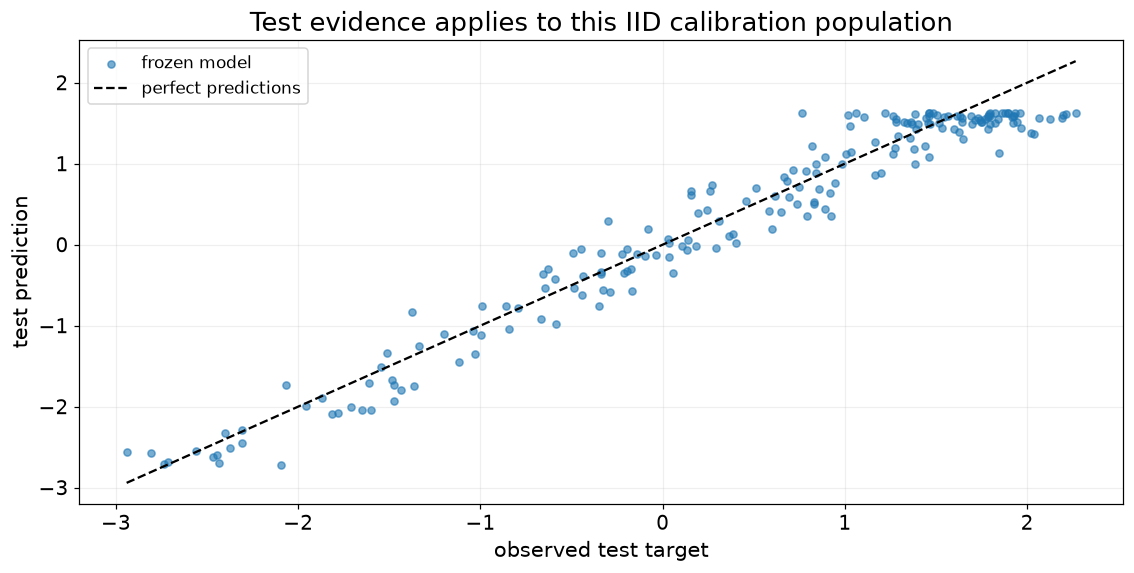

In [11]:
# Example 10: One final test report for the frozen pipeline
candidate_records = [(row[2], "polynomial", row[0]) for row in degree_rows]
candidate_records += [(row[2], "ridge", row[0]) for row in ridge_rows]
selected_validation, selected_kind, selected_setting = min(candidate_records, key=lambda x: x[0])


def selected_predict(x):
    if selected_kind == "polynomial":
        return design(x, selected_setting)@degree_models[selected_setting]
    return np.column_stack([np.ones(len(x)), transform(x)])@ridge_models[selected_setting]


test_predictions = selected_predict(x_test)
baseline_prediction = np.full_like(y_test, y_train.mean())
test_mse = mse(test_predictions, y_test)
baseline_mse = mse(baseline_prediction, y_test)
print("FROZEN:", selected_kind, selected_setting)
print(f"Selected validation MSE: {selected_validation:.5f} (selection score)")
print(f"Test MSE: {test_mse:.5f}; test RMSE: {math.sqrt(test_mse):.5f}")
print(f"Training-mean baseline test MSE: {baseline_mse:.5f}")
plt.scatter(y_test, test_predictions, s=22, alpha=0.6, label="frozen model")
limits = [float(y_test.min()), float(y_test.max())]
plt.plot(limits, limits, "k--", label="perfect predictions")
plt.xlabel("observed test target"); plt.ylabel("test prediction")
plt.title("Test evidence applies to this IID calibration population")
plt.legend(); finish("06_final_test")

Scalers, imputers, PCA, and feature selection are fitted using only the training split (inside each training fold during cross-validation). A transformation learned from held-out data invalidates the holdout protocol.

In [12]:
# Example 11: A small normalization-leakage calculation
scale_train = np.array([0., 2.])
scale_heldout = np.array([10.])
train_mean = scale_train.mean()
pooled_mean = np.concatenate([scale_train, scale_heldout]).mean()
print("Training-only mean:", train_mean, "pooled mean:", pooled_mean)
print("Correct centered training values:", scale_train-train_mean)
print("Correct centered held-out value:", scale_heldout-train_mean)
print("Leaked centered training values:", scale_train-pooled_mean)
assert train_mean == 1 and pooled_mean == 4

Training-only mean: 1.0 pooled mean: 4.0
Correct centered training values: [-1.  1.]
Correct centered held-out value: [9.]
Leaked centered training values: [-4. -2.]


Row-split train/validation shared subjects: 12
Grouped train / val / test subject IDs: [[0, 1, 3, 4, 5, 7, 10, 11], [6, 8], [2, 9]]
Known-subject validation MSE: 0.00966
Unseen-subject validation MSE: 5.95351
Different claims and different samples: this is not a controlled model ranking.


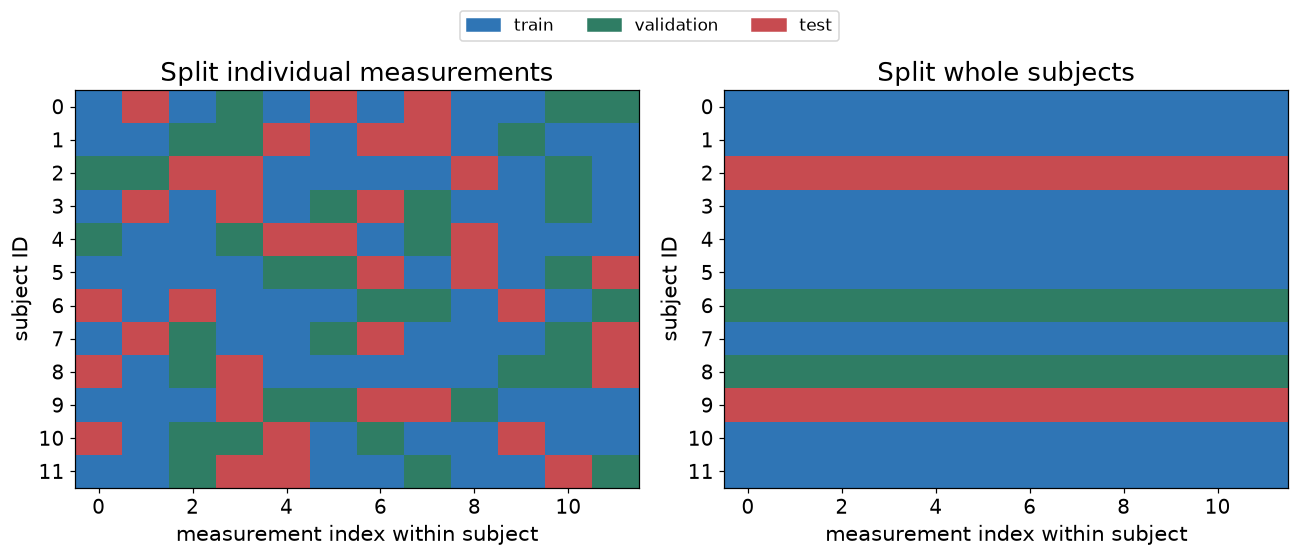

In [13]:
# Example 12: Construct row and subject splits; audit identities
group_rng = np.random.default_rng(83)
n_subjects, rows_per_subject = 12, 12
subject = np.repeat(np.arange(n_subjects), rows_per_subject)
gx = group_rng.uniform(-1, 1, (len(subject), 1))
offsets = group_rng.normal(0, 2, (n_subjects, 1))
gy = 2*gx+offsets[subject]+0.1*group_rng.normal(size=gx.shape)
row_parts = [[], [], []]
for sid in range(n_subjects):
    shuffled = group_rng.permutation(np.flatnonzero(subject == sid))
    for bucket, ids in zip(row_parts, [shuffled[:6], shuffled[6:9], shuffled[9:]]):
        bucket.extend(ids)
row_train, row_val, row_test = [np.array(ids) for ids in row_parts]
subject_order = group_rng.permutation(n_subjects)
group_train, group_val, group_test = [np.flatnonzero(np.isin(subject, ids))
    for ids in [subject_order[:8], subject_order[8:10], subject_order[10:]]]
group_sets = [set(subject[ids]) for ids in [group_train, group_val, group_test]]
assert all(group_sets[i].isdisjoint(group_sets[j]) for i in range(3) for j in range(i+1, 3))
assert len(set(group_train) | set(group_val) | set(group_test)) == len(subject)


def offset_predict(train_ids, eval_ids):
    residual = gy[train_ids]-2*gx[train_ids]
    global_offset = residual.mean()
    learned = {sid: residual[subject[train_ids] == sid].mean()
               for sid in np.unique(subject[train_ids])}
    estimated_offset = np.array([learned.get(sid, global_offset)
                                 for sid in subject[eval_ids]]).reshape(-1, 1)
    return 2*gx[eval_ids]+estimated_offset


row_val_mse = mse(offset_predict(row_train, row_val), gy[row_val])
group_val_mse = mse(offset_predict(group_train, group_val), gy[group_val])
print("Row-split train/validation shared subjects:", len(set(subject[row_train]) & set(subject[row_val])))
print("Grouped train / val / test subject IDs:", [sorted(map(int, s)) for s in group_sets])
print(f"Known-subject validation MSE: {row_val_mse:.5f}")
print(f"Unseen-subject validation MSE: {group_val_mse:.5f}")
print("Different claims and different samples: this is not a controlled model ranking.")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, parts, title in zip(axes, [[row_train, row_val, row_test],
                                  [group_train, group_val, group_test]],
                            ["Split individual measurements", "Split whole subjects"]):
    membership = np.zeros(len(subject), dtype=int)
    for label, ids in enumerate(parts):
        membership[ids] = label
    from matplotlib.colors import ListedColormap
    ax.imshow(membership.reshape(n_subjects, rows_per_subject), aspect="auto",
              cmap=ListedColormap(COLORS[:3]), vmin=0, vmax=2, interpolation="nearest")
    ax.set(title=title, xlabel="measurement index within subject", ylabel="subject ID")
    ax.set_yticks(range(n_subjects)); ax.grid(False)
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=c, label=l) for c, l in zip(COLORS, ["train", "validation", "test"])],
           loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.07))
finish("07_group_splits")

Raw recordings or time blocks are split before window extraction; boundary-crossing windows are discarded. Any additional gap depends on input history, label horizon, and dependence structure. Non-overlap alone does not prove statistical independence. Grouping by session still shares subjects when a person has several sessions; grouping must match the intended use.

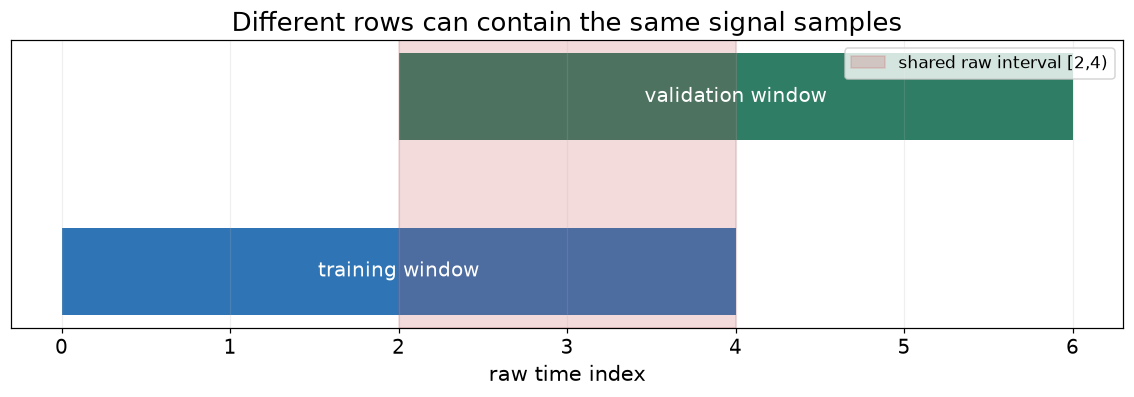

Shared interval length: 2


In [14]:
# Example 13: Visualize shared raw observations
windows = [(0, 4, "training window"), (2, 6, "validation window")]
fig, ax = plt.subplots(figsize=(10.5, 3.8))
for i, (start, end, label) in enumerate(windows):
    ax.broken_barh([(start, end-start)], (i-0.25, 0.5), facecolors=COLORS[i])
    ax.text((start+end)/2, i, label, ha="center", va="center", color="white")
ax.axvspan(2, 4, color=COLORS[2], alpha=0.2, label="shared raw interval [2,4)")
ax.set(xlabel="raw time index", yticks=[], title="Different rows can contain the same signal samples")
ax.legend(loc="upper right"); finish("08_window_overlap")
print("Shared interval length:", max(0, min(4, 6)-max(0, 2)))

Here 20 predeclared independent synthetic trials regenerate training and
evaluation observations. Fixed recipes use the same data within each trial. These are simulation evaluation sets, not repeated looks at the primary test set; all trials are reported.

degree 1: MSE mean=0.29543; sample SD=0.03517; n=20 datasets
degree 2: MSE mean=0.07294; sample SD=0.01157; n=20 datasets
degree 9: MSE mean=8.52231; sample SD=13.93450; n=20 datasets


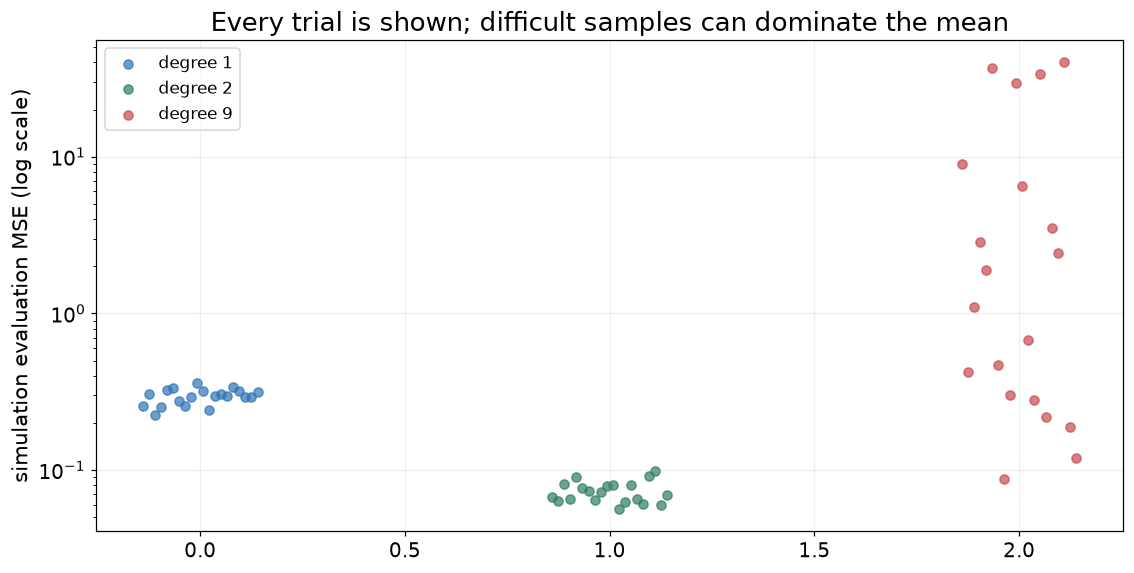

In [21]:
# Example 14: Report variability across independent synthetic datasets
repeat_seeds = list(range(100, 120))
repeat_scores = []
for seed in repeat_seeds:
    rng = np.random.default_rng(seed)
    xr, yr = sample_data(rng, 18)
    xe, ye = sample_data(rng, 200)
    values = []
    for degree in [1, 2, 9]:
        coef = np.linalg.lstsq(design(xr, degree), yr, rcond=None)[0]
        values.append(mse(design(xe, degree)@coef, ye))
    repeat_scores.append(values)
repeat_scores = np.array(repeat_scores)
for j, degree in enumerate([1, 2, 9]):
    print(f"degree {degree}: MSE mean={repeat_scores[:,j].mean():.5f}; "
          f"sample SD={repeat_scores[:,j].std(ddof=1):.5f}; n=20 datasets")
for j, (degree, color) in enumerate(zip([1, 2, 9], COLORS)):
    plt.scatter(np.full(20, j)+np.linspace(-0.14, 0.14, 20), repeat_scores[:,j],
                color=color, alpha=0.7, label=f"degree {degree}")
# plt.xticks(range(3), ["degree 1", "degree 2", "degree 9"])
plt.yscale("log"); plt.ylabel("simulation evaluation MSE (log scale)")
plt.title("Every trial is shown; difficult samples can dominate the mean")
plt.legend(); finish("09_repeated_datasets")

The following explicitly hypothetical per-subject MSEs illustrate a 95%
percentile bootstrap interval for a fixed model's **equal-subject mean**.
Subjects are assumed independent and representative. This is approximate,
especially with only 12 subjects. It does not cover training/model-selection
uncertainty or guarantee performance under distribution shift.

Equal-subject mean MSE=0.45000; subject SD=0.21967
Approximate 95% subject-bootstrap interval: [0.33750, 0.57585]


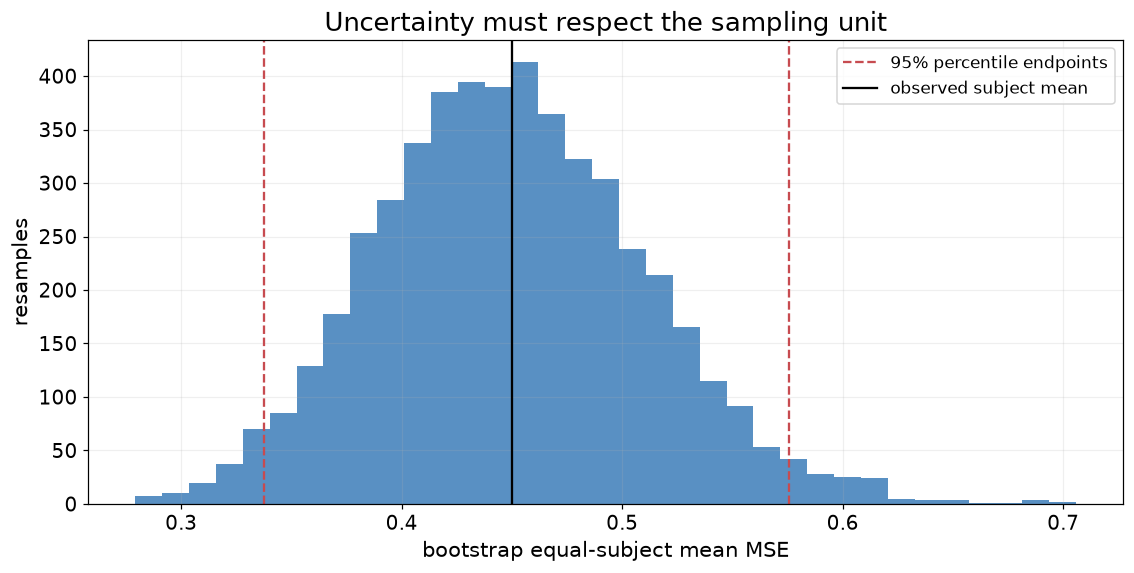

In [22]:
# Example 15: Resample the independent unit
subject_mse = np.array([0.18, 0.22, 0.25, 0.31, 0.34, 0.40,
                        0.44, 0.48, 0.51, 0.63, 0.72, 0.92])
bootstrap_rng = np.random.default_rng(41)
indices = bootstrap_rng.integers(0, len(subject_mse), (5000, len(subject_mse)))
bootstrap_means = subject_mse[indices].mean(axis=1)
ci_low, ci_high = np.quantile(bootstrap_means, [0.025, 0.975])
print(f"Equal-subject mean MSE={subject_mse.mean():.5f}; "
      f"subject SD={subject_mse.std(ddof=1):.5f}")
print(f"Approximate 95% subject-bootstrap interval: [{ci_low:.5f}, {ci_high:.5f}]")
plt.hist(bootstrap_means, bins=35, color=COLORS[0], alpha=0.8)
plt.axvline(ci_low, color=COLORS[2], ls="--", label="95% percentile endpoints")
plt.axvline(ci_high, color=COLORS[2], ls="--")
plt.axvline(subject_mse.mean(), color="black", label="observed subject mean")
plt.xlabel("bootstrap equal-subject mean MSE"); plt.ylabel("resamples")
plt.title("Uncertainty must respect the sampling unit")
plt.legend(); finish("10_subject_uncertainty")

In [17]:
# Example 16: Reveal exit-ticket answers after discussion
print("1. Validation comparison under the intended split; final frozen-model test evidence.")
exit_weight = 2-0.05*(-0.4+0.1*2)
assert np.isclose(exit_weight, 2.01)
print("2. New weight =", exit_weight, "; the data gradient can outweigh shrinkage.")
print("3. Shared subjects, overlapping raw windows, duplicates, or fitted preprocessing.")
print("4. No. Initialization spread is conditional on those data and that evaluation split.")

1. Validation comparison under the intended split; final frozen-model test evidence.
2. New weight = 2.01 ; the data gradient can outweigh shrinkage.
3. Shared subjects, overlapping raw windows, duplicates, or fitted preprocessing.
4. No. Initialization spread is conditional on those data and that evaluation split.


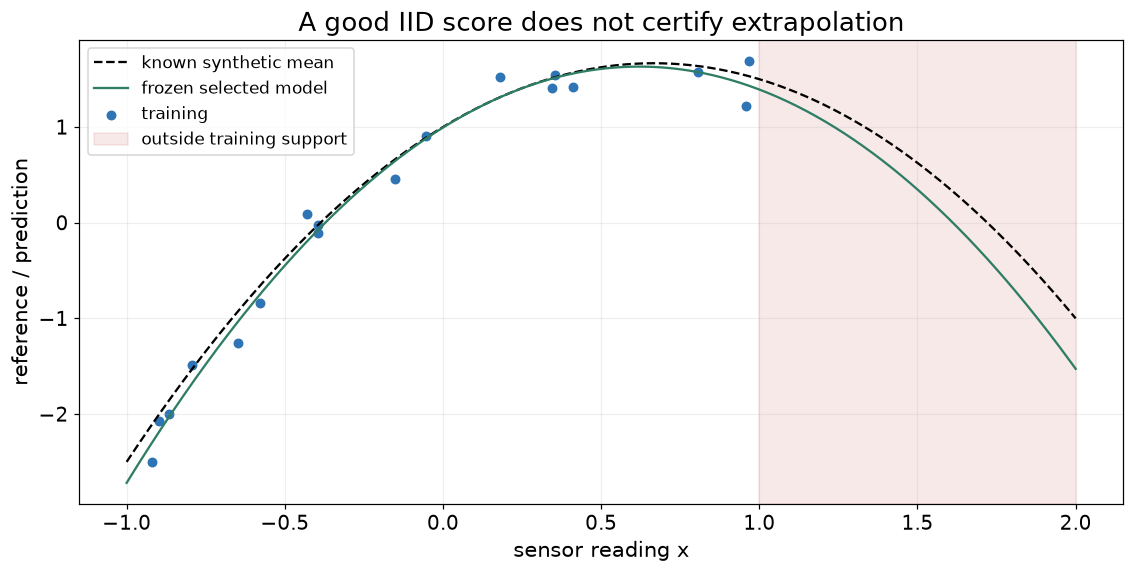

In [18]:
# Example 17: Visualize the limits of the evaluation claim
wide_grid = np.linspace(-1, 2, 500).reshape(-1, 1)
plt.plot(wide_grid, true_law(wide_grid), "k--", label="known synthetic mean")
plt.plot(wide_grid, selected_predict(wide_grid), color=COLORS[1], label="frozen selected model")
plt.scatter(x_train, y_train, s=30, color=COLORS[0], label="training")
plt.axvspan(1, 2, color=COLORS[2], alpha=0.12, label="outside training support")
plt.xlabel("sensor reading x"); plt.ylabel("reference / prediction")
plt.title("A good IID score does not certify extrapolation")
plt.legend(); finish("11_extrapolation")